# PitWall-X — Tyre Degradation & Fuel-Corrected Pace

This notebook is made to study and develop the project pipeline incrementally:
Setup -> Data Loading -> EDA -> Preprocessing & Feature Engineering -> (Modelling) -> (Evaluation).

The analysis is developed first on a single race (Bahrain 2023), then generalised across multiple races within the same regulation era via a reusable function.

## Phase 0: Setup
Setting up FastF1 where we will be gathering our data for the project.

In [2]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

fastf1.Cache.enable_cache("../cache/")

## Phase 1: Data Loading — Bahrain Grand Prix 2023

We are starting by analyzing one race, preferably in a race where the circuit is pretty stable with overtaking opportunities, balanced pace etc. One of the choices is the Bahrain circuit, it's special because it's where tyre degradation appears to be and there are lots of overtakings, one of the reasons why it's the pre-season testing circuit so it's where teams actually test their cars before the season begins.

We load and analyze the race data.

In [3]:
bahrain2023_race = fastf1.get_session(2023, "Bahrain", "R")
bahrain2023_race.load()
laps = bahrain2023_race.laps
results = bahrain2023_race.results

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


## Phase 2: Exploratory Data Analysis (EDA)

### 2.1 Inspecting the raw data
First we inspect the shape, the available columns, their data types, and a sample of rows to understand what FastF1 gives us.

In [4]:
print(laps.shape)
print(laps.columns)
print(laps.dtypes)
print(laps.head())

(1056, 31)
Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')
Time                  timedelta64[ns]
Driver                         object
DriverNumber                   object
LapTime               timedelta64[ns]
LapNumber                     float64
Stint                         float64
PitOutTime            timedelta64[ns]
PitInTime             timedelta64[ns]
Sector1Time           timedelta64[ns]
Sector2Time           timedelta64[ns]
Sector3Time           timedelta64[ns]
Sector1SessionTime    timedelta64[ns]
Sector2SessionTime    timedel

In [5]:
print(results.shape)
print(results.columns)
print(results.dtypes)
print(results.head())
results["Status"].unique()

(20, 22)
Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')
DriverNumber                   object
BroadcastName                  object
Abbreviation                   object
DriverId                       object
TeamName                       object
TeamColor                      object
TeamId                         object
FirstName                      object
LastName                       object
FullName                       object
HeadshotUrl                    object
CountryCode                    object
Position                      float64
ClassifiedPosition             object
GridPosition                  float64
Q1                    timedelta64[ns]
Q2                    timedelta64[ns]
Q3                    timed

array(['Finished', 'Lapped', 'Retired'], dtype=object)

### 2.2 Cleaning, missing values, and stint overview
Before going forward we have to clean our data, there are laps that don't count, either in/out laps, laps under safety car, invalid laps etc and we need to fixate on one driver to actually have a consistent experiment piece before moving to generalization.

We convert lap times to seconds, cast the stint to an integer, keep only accurate laps, report missing values, and print each driver's stint lengths.

In [6]:
laps["LapTimeSeconds"] = laps["LapTime"].dt.total_seconds()
laps["Stint"] = laps["Stint"].astype(int)
clean_laps = laps[laps["IsAccurate"] == True].copy()
finisher_mask = results["Status"].isin(["Finished", "Lapped"])
finisher_abbrevs = results[finisher_mask]["Abbreviation"].tolist()
finisher_laps = clean_laps[clean_laps["Driver"].isin(finisher_abbrevs)].copy()
drivers = finisher_laps["Driver"].unique()
print(f"All drivers: {clean_laps['Driver'].nunique()}, finishers: {finisher_laps['Driver'].nunique()}")
print(f"Dropped (retired): {set(clean_laps['Driver'].unique()) - set(finisher_abbrevs)}")
print(f"Missed values: \n{clean_laps.isna().sum()}")
for d in drivers:
    ds = finisher_laps[finisher_laps["Driver"] == d].Stint.unique()
    print("Driver: ", d)
    print(ds)
    for s in ds:
        print(f"stint {s}: ", finisher_laps[(finisher_laps["Driver"] == d) & (finisher_laps["Stint"] == s)].shape[0])

All drivers: 20, finishers: 17
Dropped (retired): {'PIA', 'OCO', 'LEC'}
Missed values: 
Time                    0
Driver                  0
DriverNumber            0
LapTime                 0
LapNumber               0
Stint                   0
PitOutTime            914
PitInTime             914
Sector1Time             0
Sector2Time             0
Sector3Time             0
Sector1SessionTime      4
Sector2SessionTime      0
Sector3SessionTime      0
SpeedI1                 0
SpeedI2                 0
SpeedFL                 0
SpeedST                 0
IsPersonalBest          0
Compound                0
TyreLife                0
FreshTyre               0
Team                    0
LapStartTime            0
LapStartDate            0
TrackStatus             0
Position                0
Deleted                 0
DeletedReason           0
FastF1Generated         0
IsAccurate              0
LapTimeSeconds          0
dtype: int64
Driver:  VER
[1 2 3]
stint 1:  12
stint 2:  20
stint 3:  18
Driver:

### Constants:

In [7]:
START_FUEL = 109.0
RACE_LAPS = clean_laps["LapNumber"].max()
FUEL_BURN = START_FUEL/RACE_LAPS

### 2.3 Correlation check
We examine the correlation between TyreLife and FuelMass, pooled across all laps vs. within a single stint, to demonstrate the multicollinearity and how pit-stop resets break it.

In [8]:
clean_laps["FuelMass"] = START_FUEL - (FUEL_BURN * clean_laps["LapNumber"]) + 1
finisher_laps["FuelMass"] = START_FUEL - (FUEL_BURN * finisher_laps["LapNumber"]) + 1
correlation_overall = clean_laps[["TyreLife", "FuelMass", "LapTimeSeconds"]].corr()
print(f"Overall correlation: \n {correlation_overall} \n")
correlation_finisher_overall = finisher_laps[["TyreLife", "FuelMass", "LapTimeSeconds"]].corr()
print(f"Overall correlation (Finished drivers only): \n {correlation_finisher_overall} \n")
ver_stint2 = clean_laps[(clean_laps["Driver"] == "VER") & (clean_laps["Stint"] == 2)]
correlation_ver_s2 = ver_stint2[["TyreLife", "FuelMass", "LapTimeSeconds"]].corr()
print(f"Verstappen Stint 2 correlation: \n {correlation_ver_s2} \n")


Overall correlation: 
                 TyreLife  FuelMass  LapTimeSeconds
TyreLife        1.000000 -0.528751       -0.047042
FuelMass       -0.528751  1.000000        0.698811
LapTimeSeconds -0.047042  0.698811        1.000000 

Overall correlation (Finished drivers only): 
                 TyreLife  FuelMass  LapTimeSeconds
TyreLife        1.000000 -0.539088       -0.063041
FuelMass       -0.539088  1.000000        0.699680
LapTimeSeconds -0.063041  0.699680        1.000000 

Verstappen Stint 2 correlation: 
                 TyreLife  FuelMass  LapTimeSeconds
TyreLife         1.00000  -1.00000         0.02976
FuelMass        -1.00000   1.00000        -0.02976
LapTimeSeconds   0.02976  -0.02976         1.00000 



Through the results we find out that the TyreLife and FuelMass are perfectly collinear over a single stint but multiple stints decouples them which makes us identify regression. The correlation between TyreLife and LapTimeSeconds is nearly 0 meaning that fuel masks degradation and motivate correction

### 2.4 Distribution and outliers
_(To do: plot the distribution of lap times and discuss the outlier tail.)_

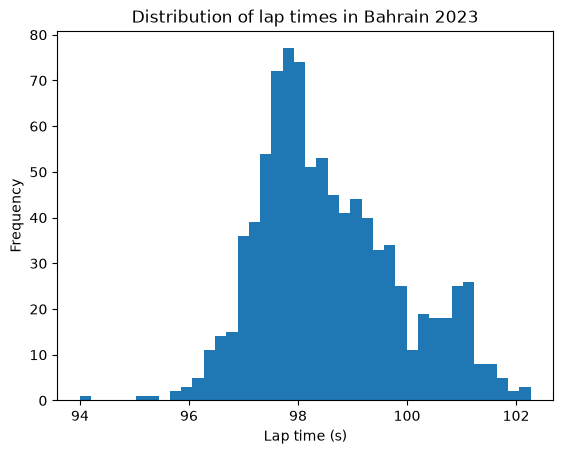

In [9]:
plt.xlabel("Lap time (s)")
plt.ylabel("Frequency")
plt.title("Distribution of lap times in Bahrain 2023")
plt.hist(clean_laps["LapTimeSeconds"], bins=40)
plt.show()

the distribution shows mild bimodality (a secondary cluster ~101s), likely reflecting distinct pace regimes (heavy-fuel early laps and/or harder compounds) consistent with our finding that fuel and compound strongly shape lap time. the bimodality is more evidence that raw lap time is a mixture of regimes (fuel, compound, phase) rather than a clean degradation signal.

### 2.5 Raw degradation plots per stint
Plotting lap time against tyre age for every driver-stint (before any fuel correction) to visualise the raw degradation behaviour.

In [10]:
for d in drivers:
    ds = clean_laps[clean_laps["Driver"] == d].Stint.unique()
    for s in ds:
        driver_stint = clean_laps[(clean_laps["Driver"] == d) & (clean_laps["Stint"] == s)]
        compound = driver_stint["Compound"].iloc[0]
        plt.xlabel("Tyre Age")
        plt.ylabel("Lap Time")
        plt.title(f"{d} Stint {s} Compound: {compound} Bahrain 2023 laptime evolution by tyre age (Lower is faster)")
        plt.plot(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['LapTimeSeconds']))
        plt.scatter(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['LapTimeSeconds']))
        plt.savefig(f"../figs/bahrain2023_{d}_stint{s}_{compound}_tyredeg_evo_scatter.png")
        plt.cla()
plt.close()

## Phase 3: Preprocessing & Feature Engineering

### 3.1 Estimating the fuel coefficient (gamma)
We need to analyze the fuel effect in the results, but before that we need to get the coefficient of how many seconds we save per kg of fuel burned. We regress lap time on tyre age and fuel mass per driver (using only finishers), and average the fuel coefficient across drivers.

In [11]:
sec_per_kg_fuel = []
for d in drivers:
    driver_laps = clean_laps[clean_laps["Driver"] == d].copy()
    if driver_laps["LapNumber"].iloc[-1] < 50.0 :
        continue
    y = driver_laps[['LapTimeSeconds']]
    driver_laps["FuelMass"] = START_FUEL - (FUEL_BURN * driver_laps["LapNumber"]) + 1
    X = driver_laps[["TyreLife", "FuelMass"]]
    laptime_predictor = LinearRegression()
    laptime_predictor.fit(X, y)
    print(f"Driver: {d}, deg_rate = {laptime_predictor.coef_[0][0]}, fuel_coef ={laptime_predictor.coef_[0][1]}")
    sec_per_kg_fuel.append(laptime_predictor.coef_[0][1])
gamma = np.mean(sec_per_kg_fuel)
per_lap_gain = gamma * FUEL_BURN
race_cum_gain = per_lap_gain * 57
print(f"Mean of seconds earned per kg: {gamma}")
print(f"Per-lap gain in seconds: {per_lap_gain}")
print(f"Race gain in seconds: {race_cum_gain}")

Driver: VER, deg_rate = 0.048257834156160195, fuel_coef =0.019029159102707114
Driver: GAS, deg_rate = 0.17108125173964497, fuel_coef =0.05178181037590402
Driver: PER, deg_rate = 0.07864057877440597, fuel_coef =0.02799122138024435
Driver: ALO, deg_rate = 0.10825465860331517, fuel_coef =0.040848078000197546
Driver: STR, deg_rate = 0.12740757826327953, fuel_coef =0.04362048864341722
Driver: SAR, deg_rate = 0.16063828183575815, fuel_coef =0.04256943466319926
Driver: MAG, deg_rate = 0.21660975895643664, fuel_coef =0.04843709506863638
Driver: DEV, deg_rate = 0.17742970515828793, fuel_coef =0.0512165617113019
Driver: TSU, deg_rate = 0.15736704066491417, fuel_coef =0.0480639700806829
Driver: ALB, deg_rate = 0.14649786080667046, fuel_coef =0.039312215177561664
Driver: ZHO, deg_rate = 0.17722875335564964, fuel_coef =0.05725646485829636
Driver: HUL, deg_rate = 0.22237779563549143, fuel_coef =0.0508816355942428
Driver: NOR, deg_rate = 0.06723670405521133, fuel_coef =0.045787526346744746
Driver: HA

### 3.2 Applying the fuel correction
We compute fuel mass on every clean lap and subtract the fuel time penalty to obtain the fuel-corrected lap time, then re-plot degradation per stint on the corrected times.

In [12]:
clean_laps["FuelMass"] = START_FUEL - (FUEL_BURN * clean_laps["LapNumber"]) + 1
clean_laps["FuelCorrectedLapTime"] = clean_laps["LapTimeSeconds"] - gamma * clean_laps["FuelMass"]
print(clean_laps[["LapNumber", "Driver", "LapTimeSeconds", "FuelMass", "FuelCorrectedLapTime"]])
for d in drivers:
    ds = clean_laps[clean_laps["Driver"] == d].Stint.unique()
    for s in ds:
        driver_stint = clean_laps[(clean_laps["Driver"] == d) & (clean_laps["Stint"] == s)]
        compound = driver_stint["Compound"].iloc[0]
        plt.xlabel("Tyre Age")
        plt.ylabel("Lap Time")
        plt.title(f"{d} Stint {s} Compound: {compound} Bahrain 2023 laptime evolution by tyre age (Fuel-corrected) (Lower is faster)")
        plt.plot(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['FuelCorrectedLapTime']))
        plt.savefig(f"../figs/bahrain2023_{d}_stint{s}_{compound}_tyredeg_evo_fuel_corrected_line.png")
        plt.scatter(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['FuelCorrectedLapTime']))
        plt.savefig(f"../figs/bahrain2023_{d}_stint{s}_{compound}_tyredeg_evo_fuel_corrected_scatter.png")
        plt.cla()
plt.close()

      LapNumber Driver  LapTimeSeconds    FuelMass  FuelCorrectedLapTime
1           2.0    VER          97.974  106.175439             93.487868
2           3.0    VER          98.006  104.263158             93.600666
3           4.0    VER          97.976  102.350877             93.651463
4           5.0    VER          98.035  100.438596             93.791261
5           6.0    VER          97.986   98.526316             93.823059
...         ...    ...             ...         ...                   ...
1050        8.0    PIA         101.295   94.701754             97.293655
1051        9.0    PIA         101.534   92.789474             97.613453
1052       10.0    PIA         101.584   90.877193             97.744250
1053       11.0    PIA         101.352   88.964912             97.593048
1054       12.0    PIA         101.156   87.052632             97.477846

[914 rows x 5 columns]


### 3.3 Compound encoding
_(To do: encode the Compound categorical feature for modelling.)_

In [13]:
finisher_laps = pd.get_dummies(finisher_laps, columns=["Compound"], drop_first=True)
print(finisher_laps.head())

                    Time Driver DriverNumber                LapTime  \
1 0 days 01:05:53.876000    VER            1 0 days 00:01:37.974000   
2 0 days 01:07:31.882000    VER            1 0 days 00:01:38.006000   
3 0 days 01:09:09.858000    VER            1 0 days 00:01:37.976000   
4 0 days 01:10:47.893000    VER            1 0 days 00:01:38.035000   
5 0 days 01:12:25.879000    VER            1 0 days 00:01:37.986000   

   LapNumber  Stint PitOutTime PitInTime            Sector1Time  \
1        2.0      1        NaT       NaT 0 days 00:00:31.342000   
2        3.0      1        NaT       NaT 0 days 00:00:31.388000   
3        4.0      1        NaT       NaT 0 days 00:00:31.271000   
4        5.0      1        NaT       NaT 0 days 00:00:31.244000   
5        6.0      1        NaT       NaT 0 days 00:00:31.341000   

             Sector2Time  ... TrackStatus Position Deleted DeletedReason  \
1 0 days 00:00:42.504000  ...          12      1.0   False                 
2 0 days 00:00:42.

Compound is a categorical feature (SOFT/MEDIUM/HARD) with no guaranteed uniform spacing between compounds, so it's one-hot encoded. drop_first=True drops HARD as the reference category to avoid perfect collinearity among the dummies and the intercept in linear models. Each remaining column lets the model learn that compound's pace/degradation effect relative to the HARD baseline.

### 3.4 Nonlinearity feature (TyreLife squared)
Adding a squared tyre-age feature to capture nonlinear degradation

In [14]:
finisher_laps["TyreLifeSquared"] = finisher_laps["TyreLife"] ** 2

In [16]:
finisher_laps[["TyreLife", "TyreLifeSquared"]]

,TyreLife,TyreLifeSquared
1,5.0,25.0
2,6.0,36.0
3,7.0,49.0
4,8.0,64.0
5,9.0,81.0
...,...,...
1038,24.0,576.0
1039,25.0,625.0
1040,26.0,676.0
1041,27.0,729.0


## Phase 4: Generalising across races
Wrapping everything to one function to automatically extract the results per race, returning the final dataset and the estimated fuel coefficient (gamma).

In [6]:
def race_analysis(gp, year):
    race = fastf1.get_session(year, gp, "R")
    race.load()
    laps = race.laps
    laps["LapTimeSeconds"] = laps["LapTime"].dt.total_seconds()
    laps["Stint"] = laps["Stint"].astype(int)
    clean_laps = laps[laps["IsAccurate"] == True].copy()
    drivers = clean_laps["Driver"].unique()
    START_FUEL = 109.0
    RACE_LAPS = clean_laps["LapNumber"].max()
    FUEL_BURN = START_FUEL/RACE_LAPS
    print(f"Laps: {RACE_LAPS}")
    sec_per_kg_fuel = []
    for d in drivers:
        driver_laps = clean_laps[clean_laps["Driver"] == d].copy()
        if driver_laps["LapNumber"].iloc[-1] < clean_laps["LapNumber"].max() - 5.0 :
            continue
        y = driver_laps[['LapTimeSeconds']]
        driver_laps["FuelMass"] = START_FUEL - (FUEL_BURN * driver_laps["LapNumber"]) + 1
        X = driver_laps[["TyreLife", "FuelMass"]]
        laptime_predictor = LinearRegression()
        laptime_predictor.fit(X, y)
        print(f"Driver: {d}, deg_rate = {laptime_predictor.coef_[0][0]}, fuel_coef ={laptime_predictor.coef_[0][1]}")
        sec_per_kg_fuel.append(laptime_predictor.coef_[0][1])
    gamma = np.mean(sec_per_kg_fuel)
    clean_laps["FuelMass"] = START_FUEL - (FUEL_BURN * clean_laps["LapNumber"]) + 1
    clean_laps["FuelCorrectedLapTime"] = clean_laps["LapTimeSeconds"] - gamma * clean_laps["FuelMass"]
    print(clean_laps[["LapNumber", "Driver", "LapTimeSeconds", "FuelMass", "FuelCorrectedLapTime"]])
    
    for d in drivers:
        ds = clean_laps[clean_laps["Driver"] == d].Stint.unique()
        for s in ds:
            driver_stint = clean_laps[(clean_laps["Driver"] == d) & (clean_laps["Stint"] == s)]
            compound = driver_stint["Compound"].iloc[0]
            plt.xlabel("Tyre Age")
            plt.ylabel("Lap Time")
            plt.title(f"{d} Stint {s} Compound: {compound} {gp} {year} laptime evolution by tyre age (Lower is faster)")
            plt.plot(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['LapTimeSeconds']))
            plt.savefig(f"../figs/{gp}{year}_{d}_stint{s}_{compound}_tyredeg_evo.png")
            plt.cla()
    plt.close()

    return clean_laps, gamma

race_data = race_analysis("Miami", 2024)
print(race_data[0])
print(f"Gamma: {race_data[1]}")

core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '16', '11', '55', '44', '22', '63', '14', '31', '27', '10', '81', '24', '3', '77', '18', '23', '20', '2']


Laps: 57.0
Driver: VER, deg_rate = 0.03079868124621089, fuel_coef =0.02780291670444947
Driver: GAS, deg_rate = 0.01360326035104375, fuel_coef =0.02367755967217189
Driver: PER, deg_rate = 0.004795067660458852, fuel_coef =0.025772082120717972
Driver: ALO, deg_rate = 0.024135948285333286, fuel_coef =0.032887091613266535
Driver: LEC, deg_rate = 0.027961501405798353, fuel_coef =0.03057877192046853
Driver: STR, deg_rate = -0.011189915391207467, fuel_coef =0.018907725858455793
Driver: MAG, deg_rate = 0.06228169375063772, fuel_coef =0.03812806365157197
Driver: TSU, deg_rate = 0.015907353421673587, fuel_coef =0.03127690005179183
Driver: ALB, deg_rate = 0.03329644709194948, fuel_coef =0.02933162501616366
Driver: ZHO, deg_rate = 0.0031524782174623465, fuel_coef =0.02207985055730322
Driver: HUL, deg_rate = 0.03419389854230272, fuel_coef =0.029220068403205186
Driver: RIC, deg_rate = -0.0038384730125407564, fuel_coef =0.02328354731275935
Driver: OCO, deg_rate = 0.020839679518106675, fuel_coef =0.027

## Phase 5: Modelling
_(To do: train at least two model types and compare them.)_

## Phase 6: Evaluation
_(To do: define a baseline, use a held-out split, and compare model performance against it.)_